In [ ]:
2from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd drive/MyDrive/zeroday/zeroday/CODE/

/content/drive/MyDrive/zeroday/zeroday/CODE


In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split

In [ ]:
# Load NSL-KDD dataset (change path if necessary)
train = pd.read_csv("DataFiles/NSL/KDDTrain+.txt", header=None)
test= pd.read_csv("DataFiles/NSL/KDDTest+.txt", header=None)

In [ ]:
ls

 10-fold-OC-SVM-NSL-KDD.ipynb       cnnids.json
 1_oneclass_svm_NSLKDD.ipynb        cnnids.weights.h5
 20n_kmean.json                    'Copy of CICIDS2017_ZeroDay_IDS.ipynb'
 2_CNN__OCSVM_NSLKDD.ipynb          DataFiles/
 3-Fuzzy-Oneclass-SVM.ipynb         KDDTest+.txt
 5-4-2025_CICIDS2017.ipynb          KDDTrain+.txt
 Autoencoder+OCSVM.ipynb            kmean.keras
 CICIDS2017_Friday_Balanced.csv     kmean.weights.h5
 CICIDS2017_Friday.ipynb            model_plot_CNN.pdf
 cicids2017.keras                   model_plot_CNN.png
 CICIDS2017_THURDAY.ipynb           model_plot_CNN.svg
 CICIDS2017_Thursday_Balanced.csv   unswnb15.keras
 cicids2017.weights.h5              UNSW_NB15_selected.csv
 cnnids1.json                       Untitled0.ipynb


In [ ]:
train_df = pd.concat([train, test], axis=0)  # axis=0 means vertical concatenation

In [ ]:
# Column names from NSL-KDD description
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

In [ ]:
train_df.columns = columns
#test_df.columns = columns

In [ ]:
# Drop the 'difficulty' column (not useful)
train_df.drop("difficulty", axis=1, inplace=True)
#test_df.drop("difficulty", axis=1, inplace=True)

In [ ]:
# Convert categorical variables into numerical values
for col in ["protocol_type", "service", "flag"]:
    encoder = LabelEncoder()
    train_df[col] = encoder.fit_transform(train_df[col])
    #test_df[col] = encoder.transform(test_df[col])

In [ ]:
# Select features and normalize
features = train_df.columns[:-1]  # Exclude label
scaler = StandardScaler()
X_train1 = scaler.fit_transform(train_df[features])
#X_test = scaler.transform(test_df[features])

In [ ]:
# Label encoding: Normal (1), Attack (-1)
#y_train1 = np.where(train_df["label"] == "normal", 1, -1)
#y_test = np.where(test_df["label"] == "normal", 1, -1)
# Label encoding: Normal (1), Attack (0)
y_train1 = np.where(train_df["label"] == "normal", 1, 0)

In [ ]:
#...................................Dont run for CNN

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_train1, y_train1, test_size=0.25, random_state=42)

In [ ]:
# Train One-Class SVM with RBF kernel with nu=0.1
oc_svm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)
oc_svm.fit(X_train[y_train == 1])  # Train only on normal traffic

OneClassSVM(nu=0.05)

In [ ]:
# Predict on test data
y_pred = oc_svm.predict(X_test)

# Replace -1 (outliers) with 0 (attacks) for consistency
y_pred = np.where(y_pred == -1, 0, y_pred)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Attack", "Normal"], digits=4))

Accuracy: 0.9096148666846215
              precision    recall  f1-score   support

      Attack     0.9384    0.8692    0.9025     17862
      Normal     0.8865    0.9471    0.9158     19268

    accuracy                         0.9096     37130
   macro avg     0.9124    0.9081    0.9091     37130
weighted avg     0.9115    0.9096    0.9094     37130



In [ ]:
# Predict on test data
y_pred = oc_svm.predict(X_test)

In [ ]:
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Attack", "Normal"],digits=4))

In [ ]:
#..........Oneclass-SVM

In [ ]:
X = np.concatenate((X_train,X_test), axis=0)
X = np.array(X)
X.shape

In [ ]:
Y=np.concatenate((y_train, y_test), axis=0)
Y=np.array(Y)
Y.shape

(29703,)

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5) # Define the split - into 2 folds
skf.get_n_splits(X_test,y_test)
print(skf)

StratifiedKFold(n_splits=5, random_state=None, shuffle=False)


In [ ]:
#.................oc-SVM.with-nu=0.1...............
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
acc=list();
prec=list();
recall=list();
f1=list();
model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.1)
#model=model = LogisticRegression()
for train_index, test_index in skf.split(X,Y):
  #print('TRAIN', train_index, “TEST:”, test_index);
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = Y[train_index], Y[test_index]
  #model.fit(X_train, y_train)
  model.fit(X_train[y_train == 1])
  y_pred=model.predict(X_test)
  y_pred = np.where(y_pred == -1, 0, 1)
  #y_pred=FRS(X_train,y_train,X_test,0.15)
  score=accuracy_score(y_test, y_pred)
  acc.append(score)
  score1=precision_score(y_test, y_pred, average='weighted')
  prec.append(score1)
  score2=recall_score(y_test, y_pred, average='weighted')
  recall.append(score2)
  score3=f1_score(y_test, y_pred, average='weighted')
  f1.append(score3)

a = np.array(acc)
print("Accuracy:",a.mean(), a.std())
b = np.array(prec)
print("Precision:",b.mean(), b.std())
c = np.array(recall)
print("Recall:",c.mean(), c.std())
d = np.array(f1)
print("F1-score:",d.mean(), d.std())

Accuracy: 0.8989664189445371 0.001135041530630123
Precision: 0.8990341830015455 0.0011516856390262774
Recall: 0.8989664189445371 0.001135041530630123
F1-score: 0.8989755382331535 0.001133253296016517


In [ ]:
#.................oc-SVM.with-nu=0.15...............
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
acc=list();
prec=list();
recall=list();
f1=list();
model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.15)
#model=model = LogisticRegression()
for train_index, test_index in skf.split(X,Y):
  #print('TRAIN', train_index, “TEST:”, test_index);
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = Y[train_index], Y[test_index]
  #model.fit(X_train, y_train)
  model.fit(X_train[y_train == 1])
  y_pred=model.predict(X_test)
  y_pred = np.where(y_pred == -1, 0, 1)
  #y_pred=FRS(X_train,y_train,X_test,0.15)
  score=accuracy_score(y_test, y_pred)
  acc.append(score)
  score1=precision_score(y_test, y_pred, average='weighted')
  prec.append(score1)
  score2=recall_score(y_test, y_pred, average='weighted')
  recall.append(score2)
  score3=f1_score(y_test, y_pred, average='weighted')
  f1.append(score3)

a = np.array(acc)
print("Accuracy:",a.mean(), a.std())
b = np.array(prec)
print("Precision:",b.mean(), b.std())
c = np.array(recall)
print("Recall:",c.mean(), c.std())
d = np.array(f1)
print("F1-score:",d.mean(), d.std())

Accuracy: 0.8826381074958756 0.0018365754492244482
Precision: 0.8853429154087646 0.001972679341851607
Recall: 0.8826381074958756 0.0018365754492244482
F1-score: 0.8826288258656394 0.0018376970442683868


In [ ]:
#.................oc-SVM.with-nu=0.2...............
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
acc=list();
prec=list();
recall=list();
f1=list();
model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.2)
#model=model = LogisticRegression()
for train_index, test_index in skf.split(X,Y):
  #print('TRAIN', train_index, “TEST:”, test_index);
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = Y[train_index], Y[test_index]
  #model.fit(X_train, y_train)
  model.fit(X_train[y_train == 1])
  y_pred=model.predict(X_test)
  y_pred = np.where(y_pred == -1, 0, 1)
  #y_pred=FRS(X_train,y_train,X_test,0.15)
  score=accuracy_score(y_test, y_pred)
  acc.append(score)
  score1=precision_score(y_test, y_pred, average='weighted')
  prec.append(score1)
  score2=recall_score(y_test, y_pred, average='weighted')
  recall.append(score2)
  score3=f1_score(y_test, y_pred, average='weighted')
  f1.append(score3)

a = np.array(acc)
print("Accuracy:",a.mean(), a.std())
b = np.array(prec)
print("Precision:",b.mean(), b.std())
c = np.array(recall)
print("Recall:",c.mean(), c.std())
d = np.array(f1)
print("F1-score:",d.mean(), d.std())

Accuracy: 0.866410953500669 0.0031974315000416723
Precision: 0.8752060702655639 0.0026023651651095017
Recall: 0.866410953500669 0.0031974315000416723
F1-score: 0.8660521738941618 0.003271978183356498


In [ ]:
#.........................................................START OF CNN-OCSVM

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_train1, y_train1, test_size=0.30, random_state=42)

In [ ]:
#print(y_train.value_counts())
#print(y_test.value_counts())
import pandas as pd

print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

1    57786
0    53601
Name: count, dtype: int64
1    19268
0    17862
Name: count, dtype: int64


In [ ]:
# Reshape for CNN
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

In [ ]:
# Check data sizes
assert X_train.shape[0] == y_train.shape[0], "Mismatch in X_train and y_train sizes!"
assert X_test.shape[0] == y_test.shape[0], "Mismatch in X_test and y_test sizes!"

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2

# Define CNN Model with L2 Regularization
def build_cnn_nsl_kdd(input_shape, dropout=0.5, l2_lambda=0.01):
    inputs = Input(shape=(input_shape, 1))  # Define input shape properly

    x = Conv1D(128, kernel_size=5, activation='relu', padding='same',
               kernel_regularizer=l2(l2_lambda))(inputs)
    x1 = MaxPooling1D(pool_size=2)(x)

    x2 = Conv1D(256, kernel_size=3, activation='relu', padding='same',
                kernel_regularizer=l2(l2_lambda))(x1)
    x3 = MaxPooling1D(pool_size=2)(x2)

    x4 = Conv1D(128, kernel_size=3, activation='relu', padding='same',
                kernel_regularizer=l2(l2_lambda))(x3)

    x5 = Flatten()(x4)

    x6 = Dense(128, activation='relu', kernel_regularizer=l2(l2_lambda))(x5)  # Fixed this line
    x7 = Dropout(dropout)(x6)

    x8 = Dense(32, activation='relu', kernel_regularizer=l2(l2_lambda))(x7)
    x9 = Dropout(dropout)(x8)

    outputs = Dense(1, activation='sigmoid')(x9)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# Example usage
input_shape = 41  # NSL-KDD has 41 features
model = build_cnn_nsl_kdd(input_shape)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 41, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 41, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,889 (1.40 MB)

 Trainable params: 365,889 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(111387, 41, 1)
(111387,)
(37130, 41, 1)
(37130,)


In [ ]:
# Define callbacks
filepath = "kmean.keras"
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=30)
mc = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [es, mc]

In [ ]:
# Train model  make epochs =100
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, callbacks=callbacks_list, batch_size=128, verbose=2)

Epoch 1/100

Epoch 1: val_accuracy improved from -inf to 0.93986, saving model to kmean.keras
871/871 - 78s - 90ms/step - accuracy: 0.9285 - loss: 0.5218 - val_accuracy: 0.9399 - val_loss: 0.2631
Epoch 2/100

Epoch 2: val_accuracy improved from 0.93986 to 0.95742, saving model to kmean.keras
871/871 - 84s - 96ms/step - accuracy: 0.9497 - loss: 0.2479 - val_accuracy: 0.9574 - val_loss: 0.2183
Epoch 3/100

Epoch 3: val_accuracy did not improve from 0.95742
871/871 - 78s - 90ms/step - accuracy: 0.9535 - loss: 0.2292 - val_accuracy: 0.9541 - val_loss: 0.2161
Epoch 4/100

Epoch 4: val_accuracy did not improve from 0.95742
871/871 - 85s - 98ms/step - accuracy: 0.9556 - loss: 0.2191 - val_accuracy: 0.9543 - val_loss: 0.2044
Epoch 5/100

Epoch 5: val_accuracy improved from 0.95742 to 0.96173, saving model to kmean.keras
871/871 - 80s - 92ms/step - accuracy: 0.9573 - loss: 0.2115 - val_accuracy: 0.9617 - val_loss: 0.1904
Epoch 6/100

Epoch 6: val_accuracy did not improve from 0.96173
871/871 - 

In [ ]:
# Predict and evaluate
predicted = model.predict(X_test)
predicted = (predicted > 0.5).astype(int)  # Convert probabilities to binary labels
print(classification_report(y_test, predicted,digits=4))

1161/1161 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step
              precision    recall  f1-score   support

           0     0.9872    0.9540    0.9703     17862
           1     0.9586    0.9885    0.9734     19268

    accuracy                         0.9719     37130
   macro avg     0.9729    0.9713    0.9718     37130
weighted avg     0.9724    0.9719    0.9719     37130



dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


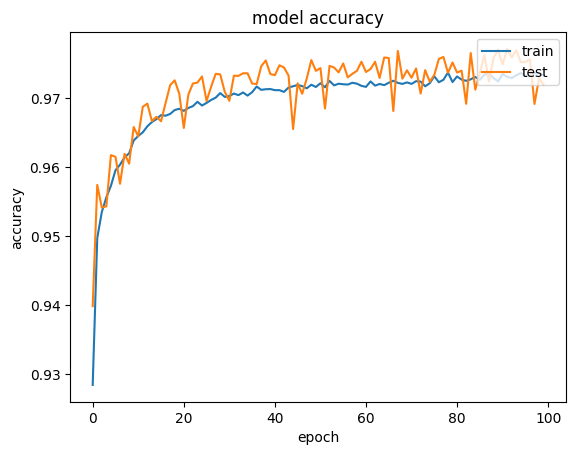

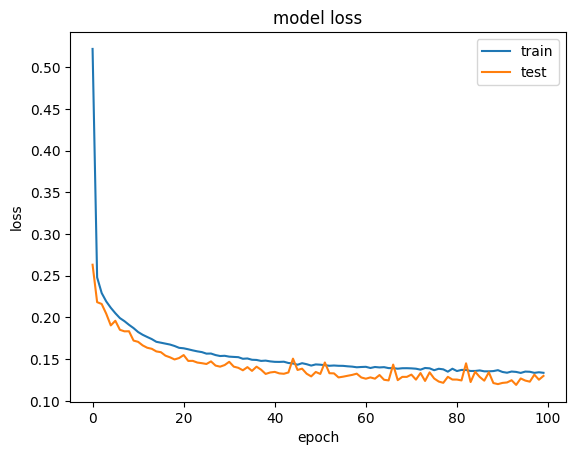

In [ ]:
#Visualize training history
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import numpy

# list all data in history
print(history.history.keys())
# summarize history for accuracy
#plt.plot(history.history['acc'])
plt.plot(history.history['accuracy'])
#plt.plot(history.history['val_acc'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')

In [ ]:
# Serialize model to JSON
model_json = model.to_json()
with open("20n_kmean.json", "w") as json_file:
    json_file.write(model_json)

In [ ]:
# ✅ Save model weights with the correct filename extension
model.save_weights("kmean.weights.h5")
print("✅ Model weights saved successfully!")

✅ Model weights saved successfully!


In [ ]:
from keras.models import model_from_json

# Load the model architecture
with open("20n_kmean.json", "r") as json_file:
    loaded_model_json = json_file.read()

loaded_model = model_from_json(loaded_model_json)

# Load model weights
loaded_model.load_weights("kmean.weights.h5")

print("✅ Loaded model from disk!")

✅ Loaded model from disk!


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Predict and evaluate
predicted = model.predict(X_test)
predicted = (predicted > 0.5).astype(int)  # Convert probabilities to binary labels
print(classification_report(y_test, predicted,digits=4))

1161/1161 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step
              precision    recall  f1-score   support

           0     0.9872    0.9540    0.9703     17862
           1     0.9586    0.9885    0.9734     19268

    accuracy                         0.9719     37130
   macro avg     0.9729    0.9713    0.9718     37130
weighted avg     0.9724    0.9719    0.9719     37130



In [ ]:
layer_name = 'dense_1'    #write 'dense 1' for your requirement
intermediate_layer_model = Model(inputs=model.input,
                                 outputs=model.get_layer(layer_name).output)
intermediate_output = intermediate_layer_model.predict(X_train)
intermediate_output1=intermediate_layer_model.predict(X_test)
print(intermediate_output.shape)
print(intermediate_output1.shape)

3481/3481 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step
(111387, 32)
(37130, 32)


In [ ]:
# Train One-Class SVM with RBF kernel with nu=0.1
oc_svm = OneClassSVM(kernel="rbf", gamma=0.002, nu=0.1)
oc_svm.fit(intermediate_output[y_train == 1])  # Train only on normal traffic
#oc_svm.fit(X_train[y_train == 1])  # Train only on normal traffic

OneClassSVM(gamma=0.002, nu=0.1)

In [ ]:
y_pred = oc_svm.predict(intermediate_output1)
import numpy as np
unique_elements = np.unique(y_pred)
print(unique_elements)
y_pred = np.where(y_pred == -1, 0, y_pred)
print(y_pred)
unique_elements = np.unique(y_pred)
print(unique_elements)
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4, target_names=["Attack", "Normal"]))

In [ ]:
pip install pydot

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import plot_model

In [ ]:
# Save model architecture as an image
plot_model(model, to_file='model_plot_CNN.png', show_shapes=True, show_layer_names=True)

print("Model architecture saved as model_plot_CNN.png")

Model architecture saved as model_plot_CNN.png


In [ ]:
#..................end of CNN-OCSVM

In [ ]:
layer_name = 'dense_1'    #write 'dense 2' for your requirement
intermediate_layer_model = Model(inputs=model.input,
                                 outputs=model.get_layer(layer_name).output)
intermediate_output = intermediate_layer_model.predict(X_train)
intermediate_output1=intermediate_layer_model.predict(X_test)
print(intermediate_output.shape)
print(intermediate_output1.shape)

3481/3481 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step
(111387, 32)
(37130, 32)


In [ ]:
intermediate_output1

array([[0.02766859, 0.        , 0.03332593, ..., 0.02982195, 0.        ,
        0.        ],
       [0.02897316, 0.        , 0.03482644, ..., 0.03113271, 0.        ,
        0.        ],
       [0.02879362, 0.        , 0.03461159, ..., 0.03094167, 0.        ,
        0.        ],
       ...,
       [0.02364013, 0.        , 0.02826384, ..., 0.02539363, 0.        ,
        0.        ],
       [0.        , 0.02719778, 0.        , ..., 0.        , 0.02718251,
        0.02942202],
       [0.0285547 , 0.        , 0.0343052 , ..., 0.0306813 , 0.        ,
        0.        ]], dtype=float32)

In [ ]:
# Train One-Class SVM with RBF kernel with nu=0.1
oc_svm = OneClassSVM(kernel="rbf", gamma=0.002, nu=0.1)
oc_svm.fit(intermediate_output[y_train == 1])  # Train only on normal traffic
#oc_svm.fit(X_train[y_train == 1])  # Train only on normal traffic

OneClassSVM(gamma=0.002, nu=0.1)

In [ ]:
y_pred = oc_svm.predict(intermediate_output1)

In [ ]:
import numpy as np


unique_elements = np.unique(y_pred)

print(unique_elements)

[-1  1]


In [ ]:
y_pred = np.where(y_pred == -1, 0, y_pred)
print(y_pred)

[1 1 1 ... 0 1 1]


In [ ]:
unique_elements = np.unique(y_pred)

print(unique_elements)

[0 1]


In [ ]:
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4, target_names=["Attack", "Normal"]))

In [ ]:
pip install pydot

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import plot_model

In [ ]:
# Save model architecture as an image
plot_model(model, to_file='model_plot_CNN.png', show_shapes=True, show_layer_names=True)

print("Model architecture saved as model_plot_CNN.png")

Model architecture saved as model_plot_CNN.png


In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, accuracy_score

# Instantiate One-Class SVM with updated nu
oc_svm = OneClassSVM(kernel="rbf", gamma=0.002, nu=0.2)

# Fit and predict as before
oc_svm.fit(X_train)  # assuming X_train contains only Normal data
y_pred = oc_svm.predict(X_test)

# Map predictions to match your labels (e.g., -1 = Attack, 1 = Normal)
y_pred = ['Normal' if val == 1 else 'Attack' for val in y_pred]

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))  # assuming y_test contains ground-truth
print(classification_report(y_test, y_pred))


In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

oc_svm = OneClassSVM(kernel="rbf", gamma=0.002, nu=0.2)
oc_svm.fit(X_train_flat)

y_pred = oc_svm.predict(X_test_flat)
y_pred = ['Normal' if val == 1 else 'Attack' for val in y_pred]

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
